## The Safest Neighborhood in Pittsburgh: Income, Greenery, & Crime
**Names:** Sammy Ramadan   Aun Abbas 

**Emails:** SJR168@pitt.edu    ara382@pitt.edu

Team Name: Team City

In this project, we aim to identify the best neighborhood in the city of Pittsburgh using a data-driven argument drawing on sources from the WPRDC.


Our "bestness" is based on the general quality of life of a neighborhood; the metrics are simple but relative. The three metrics we chose were safety, upward mobility, and green spaces/parks. 

1. Past 12 Month Household Salary (higher = better represents upward mobility)
2. Crime Incidents (lower = better represents safety)
3. Green spaces (higher = better represents societal tranquility)

Of those three, I'm representing submetrics 1 and 2. Household salary and Crime incidents.

   ++ a Bonus metric as population, which I will explain later

## Sub-Metric 1: Household Salary Past 12 Months

This dataset has one row per neighborhood. The income column is the total of all household incomes in that neighborhood added together.

**Source:** https://data.wprdc.org/dataset/pittsburgh-american-community-survey-2015-miscellaneous-data/resource/d159c6b3-f70a-439b-bd2b-0cb8735d76d4

In [9]:
#--------- THE INCOME DATA-----
# Loading the dataset
income_raw = pd.read_csv('wage_dataset.csv', encoding='utf-8-sig')

# View columns to confirm the correct one 
print(income_raw.columns)

#Select the relevant columns and change income column name if needed
income = income_raw[['Neighborhood', 'Estimate; Total: - With wage or salary income']]


# Rename for simplicity
income.columns = ['Neighborhood', 'Income']

# Convert income to numeric 
income.loc[:, 'Income'] = pd.to_numeric(income['Income'], errors='coerce')


#Remove missing values
income = income.dropna()

#Sort from highest to lowest income
income_ranked = income.sort_values('Income', ascending=False)

# Print top 10 neighbrohoods
print("TOP 10 neighborhoods by income:")
print(income_ranked.head(10))

# print top 3 neighborhoods
print("\nTop 3 neighborhoods by income:")
print(income_ranked.head(3))
#------CRIME DATA------
crime_raw = pd.read_csv('crime_dataset.csv', low_memory=False)

Index(['Neighborhood', 'Id', 'Estimate; Total:', 'Margin of Error; Total:',
       'Estimate; Total: - With wage or salary income',
       'Margin of Error; Total: - With wage or salary income',
       'Estimate; Total: - No wage or salary income',
       'Margin of Error; Total: - No wage or salary income'],
      dtype='object')
TOP 10 neighborhoods by income:
           Neighborhood  Income
68            Shadyside  6134.0
77  Squirrel Hill South  4999.0
13            Brookline  4545.0
9            Bloomfield  3724.0
53     Mount Washington  3274.0
15              Carrick  3065.0
7             Beechview  2719.0
36           Greenfield  2620.0
76  Squirrel Hill North  2609.0
72     South Side Flats  2604.0

Top 3 neighborhoods by income:
           Neighborhood  Income
68            Shadyside  6134.0
77  Squirrel Hill South  4999.0
13            Brookline  4545.0


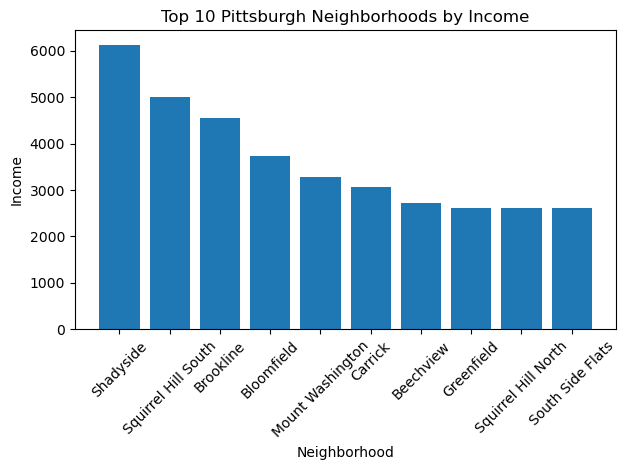

In [16]:
# bar plot  for top 10 neighborhoods
import matplotlib.pyplot as plt

#Getting the top 10
top_10_income = income_ranked.head(10)

plt.figure()

plt.bar(top_10_income['Neighborhood'], top_10_income['Income'])

plt.xticks(rotation=45)

plt.xlabel('Neighborhood')

plt.ylabel('Income')

plt.title('Top 10 Pittsburgh Neighborhoods by Income')


plt.tight_layout()
plt.show()

## Sub-Metric 2: Monthly Crime Incidents

Each row in this dataset is one crime incident reported in 2024. We count how many happened in each neighborhood.

**Source:** https://data.wprdc.org/dataset/monthly-criminal-activity-dashboard/resource/bd41992a-987a-4cca-8798-fbe1cd946b07

In [19]:
import pandas as pd 

crime_raw = pd.read_csv('crime_dataset.csv', low_memory=False)

print(crime_raw.head())
print(crime_raw['NIBRS_Offense_Type'].value_counts())
print(crime_raw.columns)

  Report_Number ReportedDate ReportedTime  Hour DayofWeek ReportedMonth  \
0  PGHP24000024     1/1/2024        00:31     0    Monday           Jan   
1  PGHP24000024     1/1/2024        00:31     0    Monday           Jan   
2  PGHP24000024     1/1/2024        00:31     0    Monday           Jan   
3  PGHP24000024     1/1/2024        00:31     0    Monday           Jan   
4  PGHP24000017     1/1/2024        00:21     0    Monday           Jan   

                           NIBRS_Coded_Offense NIBRS_Offense_Code  \
0                       13A AGGRAVATED ASSAULT                13A   
1                             13C INTIMIDATION                13C   
2                       90Z ALL OTHER OFFENSES                90Z   
3                        23H ALL OTHER LARCENY                23H   
4  9999 Vehicle Offense (Not NIBRS Reportable)                999   

   NIBRS_Offense_Category    NIBRS_Offense_Type NIBRS_Crime_Against  \
0        Assault Offenses    Aggravated Assault              Pe

## To further extrapolate on the data, I decided to include a scoring system for crime, not just to measure all crime, but the severity as well. Because ranking crime is somewhat subjective, I decided to make the system based on qualitative crime versus quantitative crime. Where crime that is more severe takes precedence over the frequency. There is some bias to this; the system takes 70% precedence towards the quality of crime over the 30% scoring for the frequency of crimes. The reasoning behind this is that, as a team, we decided that more life-threatening crimes should matter more than common petty crimes.

In [ ]:
# Crime scoring system

def crime_score(offense):
    offense = str(offense).lower()

    if 'theft' in offense or 'fraud' in offense: 
        return 1
    elif 'burglary' in offense or 'vandalism' in offense:
        return 2
    elif 'assault' in offense or 'drug' in offense:
        return 3 
    elif 'robbery' in offense or 'weapon' in offense:
        return 4 
    elif 'homicide' in offense or 'rape' in offense:
        return 5
    else:
        return 2
# Apply the scoring
crime_raw['Severity_Score'] = crime_raw['NIBRS_Offense_Type'].apply(crime_score)

In [19]:
crime_raw = pd.read_csv('crime_dataset.csv', low_memory=False)

crime_raw['Severity_Score'] = crime_raw['NIBRS_Offense_Type'].apply(crime_score)

def crime_score(offense):
    ...

print(crime_raw.columns)

# Aggregate by neighborhood
crime_summary = crime_raw.groupby('Neighborhood').agg({'Severity_Score': 'sum', 
'NIBRS_Offense_Type': 'count'
}).rename(columns={'NIBRS_Offense_Type': 'Crime_Count'})

crime_summary['Final_Score'] = (
     crime_summary['Severity_Score'] * 0.7 +
crime_summary['Crime_Count'] * 0.3
)

crime_ranked = crime_summary.sort_values('Final_Score')

print("Top 3 safest neighborhoods:")
print(crime_ranked.head(3))

Index(['Report_Number', 'ReportedDate', 'ReportedTime', 'Hour', 'DayofWeek',
       'ReportedMonth', 'NIBRS_Coded_Offense', 'NIBRS_Offense_Code',
       'NIBRS_Offense_Category', 'NIBRS_Offense_Type', 'NIBRS_Crime_Against',
       'NIBRS_Offense_Grouping', 'Violation', 'XCOORD', 'YCOORD', 'Zone',
       'Tract', 'Neighborhood', 'Block_Address', 'Severity_Score'],
      dtype='object')
Top 3 safest neighborhoods:
                Severity_Score  Crime_Count  Final_Score
Neighborhood                                            
Chartiers City              11            5          9.2
St. Clair                   27           12         22.5
Saint Clair                 54           25         45.3


This analysis uses total crime counts from the data set and my severity score without normalization due to the lack of a population column in the data set's CSV. Technically speaking, the results are correct and work the way they should, but because of the missing population column, the data favors small neighborhoods with fewer reported incidents because they're so small. To bridge the gap for the data transcrepency, I decided to include the population CSV from the WPRDC to represent crime per capita, and not artificially low crimes.

## Bonus-Sub-metric: Population (regarding criminal data)

**Source:**  https://data.wprdc.org/dataset/2020-census-redistricting-data-extracts/resource/fb2cb765-458c-4deb-8252-0a18d7ce9a78

In [28]:
# Group by neighborhood
crime_summary = crime_raw.groupby('Neighborhood').agg({
    'Severity_Score': 'sum',
    'NIBRS_Offense_Type': 'count'
}).rename(columns={'NIBRS_Offense_Type': 'Crime_Count'})

# Load population data
city_pop = pd.read_csv('city_pop.csv')


# Merge datsets 
crime_summary = crime_summary.merge(city_pop, on='Neighborhood', how='left')

# Removes missing population 
crime_summary = crime_summary.dropna(subset=['2010_Total_Population'])

#Calculate per capita rates 
crime_summary['Crime_Rate'] = crime_summary['Crime_Count'] / crime_summary['2010_Total_Population']
crime_summary['Severity_Rate'] = crime_summary['Severity_Score'] / crime_summary['2010_Total_Population']

# Final score
crime_summary['Final_Score'] = (
    crime_summary['Severity_Rate'] * 0.7 +
    crime_summary['Crime_Rate'] * 0.3
)

# Exclude Small neighborhoods
crime_summary = crime_summary[crime_summary['2010_Total_Population'] > 2000]

crime_summary = crime_summary.reset_index()

crime_ranked = crime_summary.sort_values('Final_Score')

print("Top 3 safest neighborhoods:")
print(crime_ranked[['Neighborhood', 'Final_Score']].head(3))

Top 3 safest neighborhoods:
           Neighborhood  Final_Score
45      Stanton Heights     0.096110
43  Squirrel Hill North     0.112752
30          Morningside     0.116079


In [25]:
## FINAL COMPLETE COMPILATION


# Import libraries
import os
import pandas as pd

# Show current directory
print(os.getcwd())


#-------- INCOME DATA --------

# Load dataset
income_raw = pd.read_csv('wage_dataset.csv', encoding='utf-8-sig')

# Shows column names
print(income_raw.columns)

# Selects relvant columns and changes the income column name if needed
income = income_raw[['Neighborhood', 'Estimate; Total: - With wage or salary income']]

#Rename for simplicity
income.columns = ['Neighborhood', 'Income']

#Convert income to numeric 
income.loc[:, 'Income'] = pd.to_numeric(income['Income'], errors='coerce')

#Remove missing values 
income = income.dropna()

#sort from highest to lowest income
income_ranked = income.sort_values('Income', ascending=False)

#Print top 10 neighborhoods
print("TOP 10 neighborhoods by income:")
print(income_ranked.head(10))


#Print  top 3 neighborhoods
print("\nTop 3 neighborhoods by income:")
print(income_ranked.head(3))

#CRIME DATA -
crime_raw = pd.read_csv('crime_dataset.csv', low_memory=False)

#crime scoring function 
def crime_score(offense):
    offense = str(offense).lower()

    if 'theft' in offense or 'fraud' in offense: 
        return 1
    elif 'burglary' in offense or 'vandalism' in offense:
        return 2
    elif 'assault' in offense or 'drug' in offense:
        return 3 
    elif 'robbery' in offense or 'weapon' in offense:
        return 4 
    elif 'homicide' in offense or 'rape' in offense:
        return 5
    else:
        return 2

# Apply scoring for crime
crime_raw['Severity_Score'] = crime_raw['NIBRS_Offense_Type'].apply(crime_score)

# Group by neighborhood
crime_summary = crime_raw.groupby('Neighborhood').agg({
    'Severity_Score': 'sum',
    'NIBRS_Offense_Type': 'count'
}).rename(columns={'NIBRS_Offense_Type': 'Crime_Count'})

# Load population data
city_pop = pd.read_csv('city_pop.csv')


# Merge datsets 
crime_summary = crime_summary.merge(city_pop, on='Neighborhood', how='left')

# Removes missing population 
crime_summary = crime_summary.dropna(subset=['2010_Total_Population'])

#Calculate per capita rates 
crime_summary['Crime_Rate'] = crime_summary['Crime_Count'] / crime_summary['2010_Total_Population']
crime_summary['Severity_Rate'] = crime_summary['Severity_Score'] / crime_summary['2010_Total_Population']

# Final score
crime_summary['Final_Score'] = (
    crime_summary['Severity_Rate'] * 0.7 +
    crime_summary['Crime_Rate'] * 0.3
)

# Exclude Small neighborhoods
crime_summary = crime_summary[crime_summary['2010_Total_Population'] > 2000]

crime_summary = crime_summary.reset_index()

crime_ranked = crime_summary.sort_values('Final_Score')

print("Top 3 safest neighborhoods:")
print(crime_ranked[['Neighborhood', 'Final_Score']].head(3))

/ihome/cmpinf0010-sec1010_2026s/sjr168
Index(['Neighborhood', 'Id', 'Estimate; Total:', 'Margin of Error; Total:',
       'Estimate; Total: - With wage or salary income',
       'Margin of Error; Total: - With wage or salary income',
       'Estimate; Total: - No wage or salary income',
       'Margin of Error; Total: - No wage or salary income'],
      dtype='object')
TOP 10 neighborhoods by income:
           Neighborhood  Income
68            Shadyside  6134.0
77  Squirrel Hill South  4999.0
13            Brookline  4545.0
9            Bloomfield  3724.0
53     Mount Washington  3274.0
15              Carrick  3065.0
7             Beechview  2719.0
36           Greenfield  2620.0
76  Squirrel Hill North  2609.0
72     South Side Flats  2604.0

Top 3 neighborhoods by income:
           Neighborhood  Income
68            Shadyside  6134.0
77  Squirrel Hill South  4999.0
13            Brookline  4545.0
Top 3 safest neighborhoods:
           Neighborhood  Final_Score
45      Stanton Hei

## Sub-Metric 3: City Parks (Aun Abbas)

This dataset has one row per park in Pittsburgh. We count how many parks each neighborhood has. More parks = better.

**Source:** https://data.wprdc.org/dataset/operations-green-spaces/resource/b06fa202-ead7-491c-b8f6-2702dd35f8dd

In [3]:
parks_raw = pd.read_csv('city_parks.csv')

# Group all the parks by neighborhood and count how many each one has
parks_grouped = parks_raw.groupby('neighborhood')
parks_count = parks_grouped.size()
parks = parks_count.reset_index(name='Park_Count')

# Sort from most parks to least
parks_ranked = parks.sort_values('Park_Count', ascending=False)

# Show the top 10
top_10_parks = parks_ranked.head(10)
print('Top 10 neighborhoods by number of parks:')
print(top_10_parks.to_string(index=False))


Top 10 neighborhoods by number of parks:
             neighborhood  Park_Count
             East Liberty          12
Central Business District          10
                Beechview           8
             Point Breeze           7
        South Side Slopes           7
      Squirrel Hill South           6
                Hazelwood           6
                 Sheraden           6
         Mount Washington           6
         South Side Flats           6


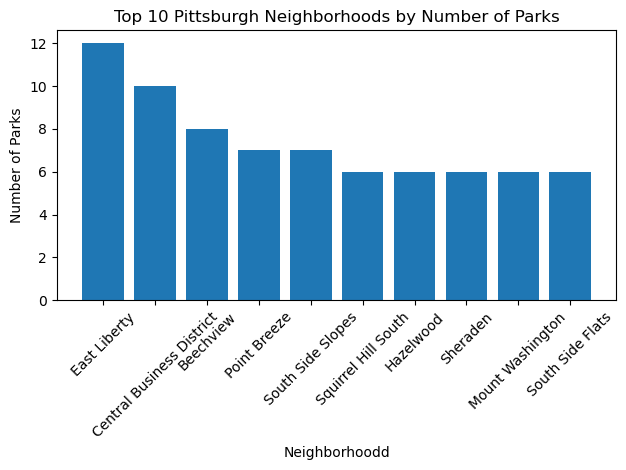

In [7]:
import matplotlib.pyplot as plt
# bar plot chart for top 10 neighborhoods
plt.figure()

plt.bar(top_10_parks['neighborhood'], top_10_parks['Park_Count'])

plt.xticks(rotation=45)

plt.xlabel('Neighborhoodd')

plt.ylabel('Number of Parks')

plt.title('Top 10 Pittsburgh Neighborhoods by Number of Parks')



plt.tight_layout()
plt.show()

In [4]:
# Get top 10 from each metric
income_top10 = income_ranked.head(10)['Neighborhood'].tolist()
crime_top10 = crime_ranked.head(10)['Neighborhood'].tolist()
parks_top10 = parks_ranked.head(10)['neighborhood'].tolist()

# Show all three side by side
print('TOP 10 INCOME          TOP 10 SAFEST          TOP 10 PARKS')
print('----------------------------------------------------------------------------')
for i in range(10):
    print(f'{i+1:2d}. {income_top10[i]:22s} {crime_top10[i]:22s} {parks_top10[i]}')

TOP 10 INCOME          TOP 10 SAFEST          TOP 10 PARKS
----------------------------------------------------------------------------
 1. Shadyside              Stanton Heights        East Liberty
 2. Squirrel Hill South    Squirrel Hill North    Central Business District
 3. Brookline              Morningside            Beechview
 4. Bloomfield             Westwood               Point Breeze
 5. Mount Washington       North Oakland          South Side Slopes
 6. Carrick                Lincoln Place          Squirrel Hill South
 7. Beechview              Banksville             Hazelwood
 8. Greenfield             Squirrel Hill South    Sheraden
 9. Squirrel Hill North    Point Breeze           Mount Washington
10. South Side Flats       Duquesne Heights       South Side Flats


## Our Conclusions

Sammy- According to the data presented, the conclusion is that Squirrel Hill (North and South) is the most common neighborhood that popped between my two metrics, meaning that the Squirrel Hill area stands out in both datasets. Incidentally, before the population metric, the data seemed somewhat inconclusive because of differing population sample sizes for criminal activity recorded. However, when the population metric is included and not artificially favoring low population for low crime, we see that Squierrl Hill (North) pops up once again, indicating relative safety and economic stability. Squirrel Hill (North/South) offers relatively the same safety as Morningside and Stanton Heights, yet with a higher salary.

Aun- I am not originally from Pittsburgh so I only really know a few neighborhoods. That said, I have been to Squirrel Hill and I can say it is a beautiful and well-maintained area. The streets are clean, the shops are nice, and it feels like a safe place to walk around. So when our data analysis picked Squirrel Hill South as the best neighborhood, I was not surprised at all. It lines up with what I have seen in person. If I had to pick a favorite neighborhood based on personal experience alone I would probably also pick Squirrel Hill just because it is one of the few areas I have actually spent time in. It was cool to see the data back up what I already felt about the neighborhood.